In [1]:
!pip install opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   -- ------------------------------------- 2.4/40.2 MB 21.3 MB/s eta 0:00:02
   ------- -------------------------------- 7.6/40.2 MB 23.7 MB/s eta 0:00:02
   ----------- ---------------------------- 11.3/40.2 MB 20.5 MB/s eta 0:00:02
   ------------------- -------------------- 19.1/40.2 MB 25.2 MB/s eta 0:00:01
   -------------------------- ------------- 26.7/40.2 MB 27.6 MB/s eta 0:00:01
   ---------------------------------- ----- 34.6/40.2 MB 29.2 MB/s eta 0:00:01
   ---------------------------------------  40.1/40.2 MB 30.3 MB/s eta 0:00:01
   ---------------------------------------- 40.2/40.2 MB 28.3 MB/s  0:00:01


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (8,6)

In [ ]:
from pathlib import Path

# Caminhos do projeto
PROJECT_ROOT = Path("..")
IMAGES_DIR = PROJECT_ROOT / "images"

CONCHA_DIR = IMAGES_DIR / "concha"
PEDRA_DIR = IMAGES_DIR / "pedra"

conchas = sorted(CONCHA_DIR.glob("*.jpg"))
pedras = sorted(PEDRA_DIR.glob("*.jpg"))

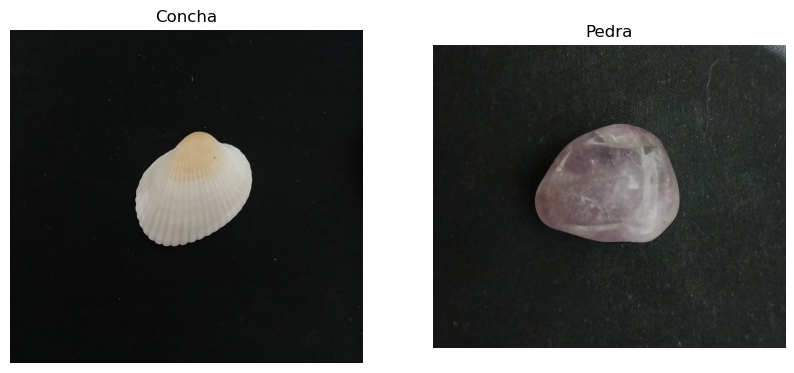

In [13]:
fig, ax = plt.subplots(1,2, figsize=(10,5))

ax[0].imshow(concha)
ax[0].set_title("Concha")

ax[1].imshow(pedra)
ax[1].set_title("Pedra")

for a in ax:
    a.axis("off")

plt.show()

In [14]:
sift = cv2.SIFT_create()

In [15]:
kp_concha, des_concha = sift.detectAndCompute(concha, None)

concha_sift = cv2.drawKeypoints(
    concha,
    kp_concha,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

In [16]:
kp_pedra, des_pedra = sift.detectAndCompute(pedra, None)

pedra_sift = cv2.drawKeypoints(
    pedra,
    kp_pedra,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

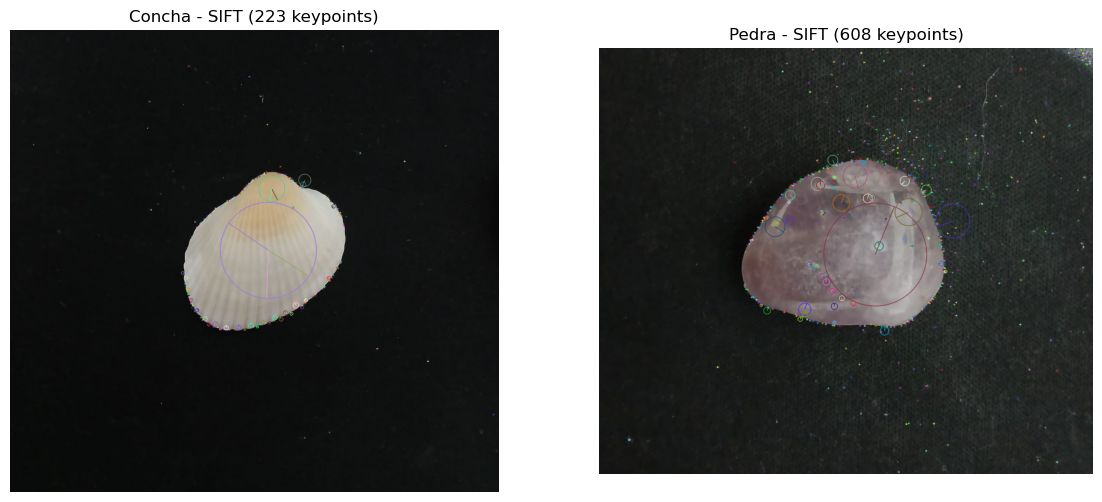

In [17]:
fig, ax = plt.subplots(1,2, figsize=(14,6))

ax[0].imshow(concha_sift)
ax[0].set_title(f"Concha - SIFT ({len(kp_concha)} keypoints)")

ax[1].imshow(pedra_sift)
ax[1].set_title(f"Pedra - SIFT ({len(kp_pedra)} keypoints)")

for a in ax:
    a.axis("off")

plt.show()

In [18]:
orb = cv2.ORB_create(200)

In [19]:
kp_concha_orb, des_concha_orb = orb.detectAndCompute(concha, None)

concha_orb = cv2.drawKeypoints(
    concha,
    kp_concha_orb,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

In [20]:
kp_pedra_orb, des_pedra_orb = orb.detectAndCompute(pedra, None)

pedra_orb = cv2.drawKeypoints(
    pedra,
    kp_pedra_orb,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

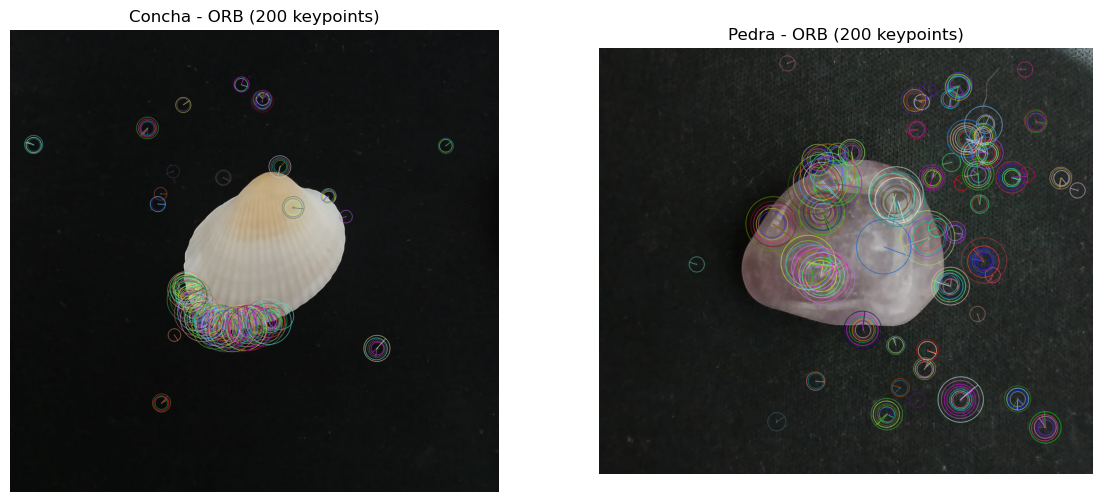

In [21]:
fig, ax = plt.subplots(1,2, figsize=(14,6))

ax[0].imshow(concha_orb)
ax[0].set_title(f"Concha - ORB ({len(kp_concha_orb)} keypoints)")

ax[1].imshow(pedra_orb)
ax[1].set_title(f"Pedra - ORB ({len(kp_pedra_orb)} keypoints)")

for a in ax:
    a.axis("off")

plt.show()

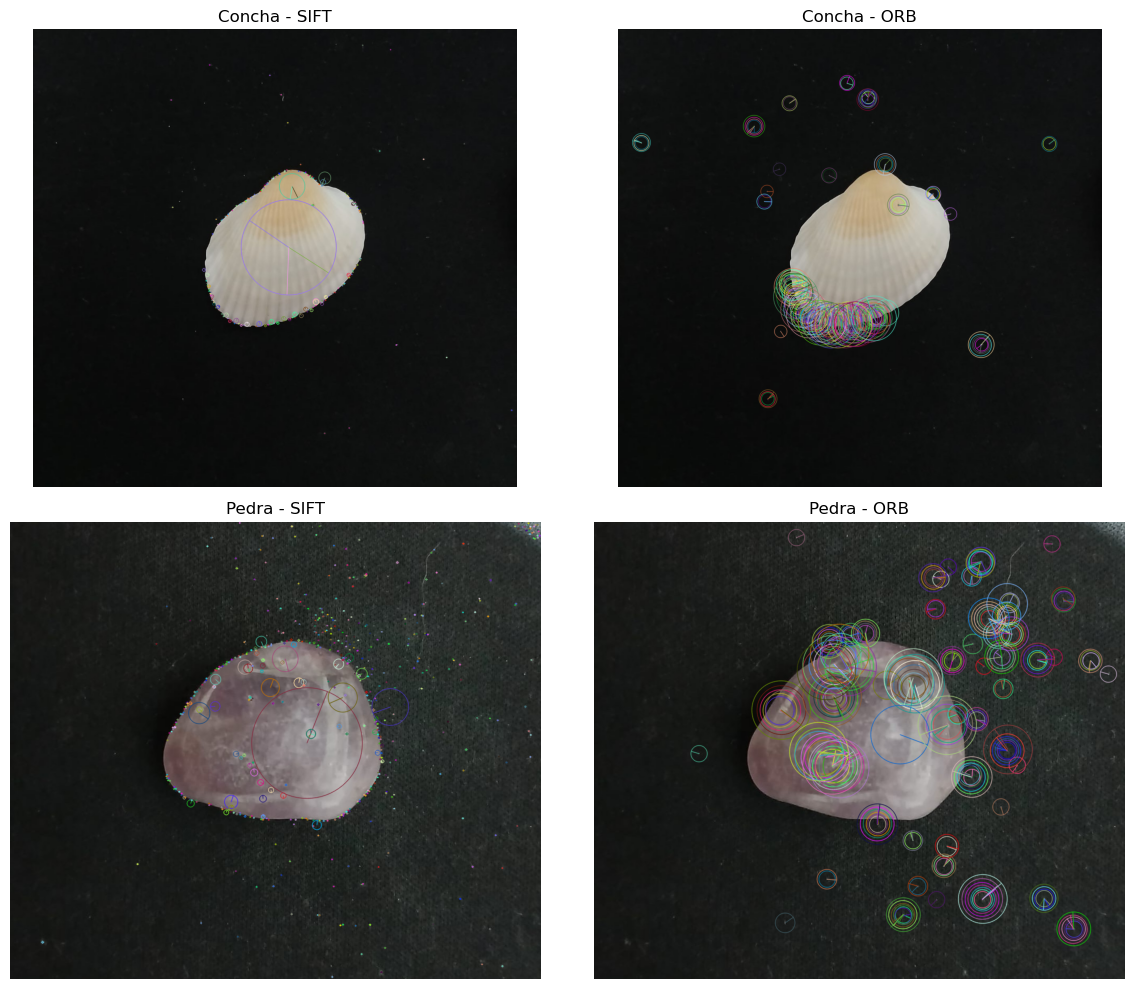

In [22]:
fig, ax = plt.subplots(2,2, figsize=(12,10))

ax[0,0].imshow(concha_sift)
ax[0,0].set_title("Concha - SIFT")

ax[0,1].imshow(concha_orb)
ax[0,1].set_title("Concha - ORB")

ax[1,0].imshow(pedra_sift)
ax[1,0].set_title("Pedra - SIFT")

ax[1,1].imshow(pedra_orb)
ax[1,1].set_title("Pedra - ORB")

for linha in ax:
    for a in linha:
        a.axis("off")

plt.tight_layout()
plt.show()

In [23]:
print("========== SIFT ==========")
print(f"Concha: {len(kp_concha)} keypoints")
print(f"Pedra : {len(kp_pedra)} keypoints")

print()

print("========== ORB ==========")
print(f"Concha: {len(kp_concha_orb)} keypoints")
print(f"Pedra : {len(kp_pedra_orb)} keypoints")

========== SIFT ==========
Concha: 223 keypoints
Pedra : 608 keypoints

========== ORB ==========
Concha: 200 keypoints
Pedra : 200 keypoints


O detector SIFT identificou pontos de interesse considerando mudanças de escala e orientação, resultando em keypoints distribuídos principalmente nas regiões de maior textura da concha e da pedra. O ORB também detectou características relevantes, porém utilizando um método mais rápido e computacionalmente eficiente. Observou-se que a quantidade e a distribuição dos keypoints variam conforme a textura e os detalhes presentes em cada objeto, evidenciando a importância da extração de características locais em tarefas como reconhecimento de objetos, correspondência entre imagens e reconstrução de cenas.